# Binary Classification with Keras
## Example: Breast Cancer Wisconsin Dataset

This notebook demonstrates a binary classification problem using Keras.
The Breast Cancer Wisconsin dataset is used as a well-known example.

In [ ]:
%pip install tensorflow

In [1]:
# Import các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

I0000 00:00:1778209491.588443   42196 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778209491.654536   42196 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778209493.131176   42196 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Load và chuẩn bị dữ liệu

In [2]:
# Load tập dữ liệu Breast Cancer
data = load_breast_cancer()

# Đặc trưng đầu vào
X = data.data

# Nhãn (0: malignant, 1: benign)
y = data.target

# Chia dữ liệu thành tập train và test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Chuẩn hóa dữ liệu để giúp mô hình học ổn định hơn
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# In thông tin cơ bản
print('Feature shape:', X.shape)
print('Target shape:', y.shape)
print('Classes:', data.target_names)

Feature shape: (569, 30)
Target shape: (569,)
Classes: ['malignant' 'benign']


## Xây dựng mô hình Keras

In [3]:
# Khởi tạo mô hình Sequential
model = Sequential()

# Lớp ẩn thứ nhất với 16 neuron, hàm kích hoạt ReLU
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Lớp ẩn thứ hai
model.add(Dense(8, activation='relu'))

# Lớp đầu ra với 1 neuron, sigmoid cho phân loại nhị phân
model.add(Dense(1, activation='sigmoid'))

# Biên dịch mô hình
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Hiển thị cấu trúc mô hình
model.summary()

/home/zhu/micromamba/envs/tf/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1778209541.051844   42196 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

## Huấn luyện mô hình

In [4]:
# Huấn luyện mô hình và lưu lại lịch sử học
# Epoch là một lần mô hình học hết toàn bộ tập dữ liệu huấn luyện
# Batch size là số mẫu được đưa vào mô hình trong mỗi lần cập nhật trọng số.
# Ví dụ: batch size = 100 nghĩa là cứ 100 mẫu thì mô hình cập nhật trọng số một lần.
# validation_split = 0.2 nghĩa là 20% dữ liệu huấn luyện sẽ được tách ra làm tập validation, 
#   và 80% còn lại dùng để train mô hình.
history = model.fit(
    X_train,
    y_train,
    epochs=50, 
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3516 - loss: 0.7443 - val_accuracy: 0.5824 - val_loss: 0.6802
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7473 - loss: 0.6494 - val_accuracy: 0.8571 - val_loss: 0.6048
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8846 - loss: 0.5607 - val_accuracy: 0.8681 - val_loss: 0.5073
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9121 - loss: 0.4391 - val_accuracy: 0.9011 - val_loss: 0.3692
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9341 - loss: 0.3160 - val_accuracy: 0.9231 - val_loss: 0.2684
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9451 - loss: 0.2315 - val_accuracy: 0.9341 - val_loss: 0.2090
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9478 - loss: 0.1832 - val_accuracy: 0.9341 - val_loss: 0.1730
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9560 - loss: 0.1523 - val_accuracy: 0.9341 - val_

## Vẽ đồ thị loss và accuracy theo epoch

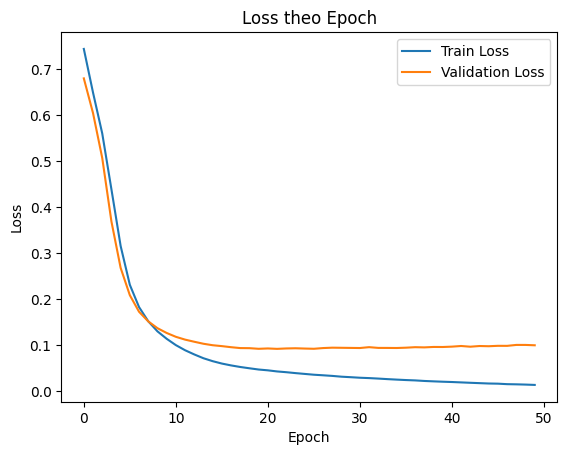

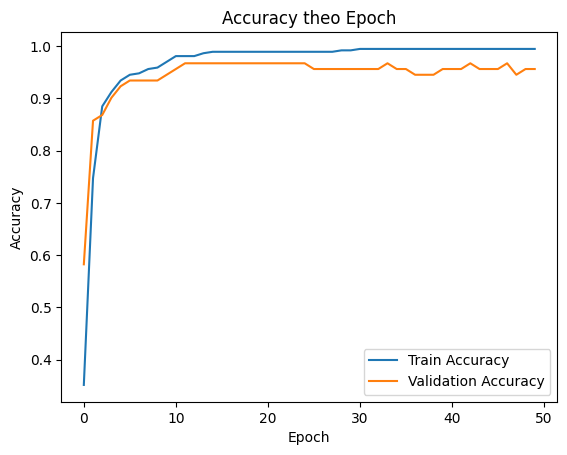

In [5]:
# Vẽ loss theo epoch
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss theo Epoch')
plt.show()

# Vẽ accuracy theo epoch
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy theo Epoch')
plt.show()

## Đánh giá mô hình trên tập test

In [6]:
# Dự đoán xác suất trên tập test
y_pred_prob = model.predict(X_test)

# Chuyển xác suất thành nhãn 0 hoặc 1
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

# Tính Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

# In Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Dự đoán trên dữ liệu mới

In [7]:
# Lấy một vài mẫu mới từ tập test để minh họa
X_new = X_test[:5]

# Dự đoán xác suất
y_new_prob = model.predict(X_new)

# Dự đoán nhãn
y_new_pred = (y_new_prob >= 0.5).astype(int)

# Hiển thị kết quả
for i in range(len(X_new)):
    print(f'Mẫu {i}: Xác suất = {y_new_prob[i][0]:.4f}, Nhãn dự đoán = {y_new_pred[i][0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Mẫu 0: Xác suất = 0.9568, Nhãn dự đoán = 1
Mẫu 1: Xác suất = 0.0000, Nhãn dự đoán = 0
Mẫu 2: Xác suất = 0.0001, Nhãn dự đoán = 0
Mẫu 3: Xác suất = 0.9998, Nhãn dự đoán = 1
Mẫu 4: Xác suất = 1.0000, Nhãn dự đoán = 1


## 9. Confusion Matrix Visualization

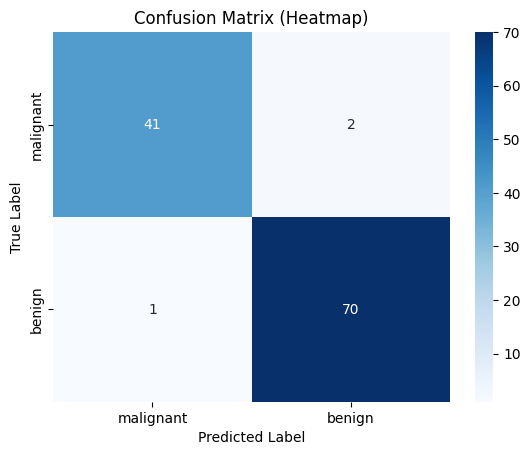

In [8]:
# Thư viện vẽ heatmap
import seaborn as sns

# Vẽ Confusion Matrix dưới dạng heatmap
plt.figure()
sns.heatmap(
    cm,
    annot=True,           # Hiển thị giá trị trong từng ô
    fmt='d',              # Định dạng số nguyên
    cmap='Blues',         # Bảng màu
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Heatmap)')
plt.show()